# Rarefaction shock with bi-Maxwellian electrons

Reproduces the simulation section of A. Diaw and P. Mora, *Rarefaction shock in
plasma with a bi-Maxwellian electron distribution function*,
[PRE **84**, 036402 (2011)](https://doi.org/10.1103/PhysRevE.84.036402),
using the `IonBoost` fluid/Lagrangian solver with **two** Boltzmann electron
populations, $n_e(\phi) = n_{hu} e^{-\phi/T_h} + n_{cu} e^{-\phi/T_c}$ (Eq. 27).

A rarefaction shock appears when $\alpha = T_h/T_c > 5 + \sqrt{24} \approx 9.9$.
The standard case of the paper is $\alpha = 10^2$, $y_u = n_{hu}/n_{cu} = 10^{-2}$.

**Units**: $n_{hu} = T_h = 1$, so time is in $\omega_{pih}^{-1}$, velocity in
$c_{sh}$, length in $\lambda_{Dh u}$, field in $E_u = \sqrt{n_{hu} k_B T_h/\varepsilon_0}$.

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'README.md').exists() and (path / 'src').exists():
            return path
    raise FileNotFoundError('repository root not found')


repo_root = find_repo_root()
build_dir = repo_root / 'build'
viz_dir = repo_root / 'scripts' / 'viz'
viz_dir.mkdir(parents=True, exist_ok=True)


def sh(*cmd, cwd=None):
    proc = subprocess.run([str(c) for c in cmd], cwd=cwd, capture_output=True, text=True)
    if proc.returncode != 0:
        print(proc.stdout[-2000:])
        print(proc.stderr[-2000:])
        raise RuntimeError(f'command failed: {cmd}')
    return proc


sh('cmake', '-S', repo_root / 'src', '-B', build_dir, '-DCMAKE_BUILD_TYPE=Release')
sh('cmake', '--build', build_dir)
print('build ok')

build ok


## 1. Runs

Standard case $\alpha = 100$, $y_u = 10^{-2}$ ($n_{hu}=1$, $n_{cu}=100$,
$T_h=1$, $T_c=0.01$) at $\omega_{pih} t = 20, 100, 500$, plus the hot-only
reference ($y_u = \infty$) used in Fig. 14 of the paper. The foil is thick
enough ($L = 60$) that the bulk rarefaction, moving at
$c_s(y_u) \approx 0.1\,c_{sh}$, never reaches the rear side.

In [2]:
alpha = 100.0
yu = 1.0e-2
nhu, Th = 1.0, 1.0
ncu, Tc = nhu / yu, Th / alpha


def input_text(tmax, cold, lmax=60.0, ncell=2450, nvacuum=400, prog=0.996, dti=0.1,
               ncold=None):
    text = (f"{ncell} {nvacuum} {prog}\n"
            f"100000 {tmax}\n"
            "20 10 5 5\n"
            f"{dti}\n"
            f"{nhu}\n"
            f"{Th}\n"
            f"T {lmax}\n"
            "F F\n"
            "1.0 4.88 20.0\n")
    if cold:
        text += f"{ncu if ncold is None else ncold} {Tc}\n"
    return text


def read_solver_table(path):
    with open(path) as fh:
        names = fh.readline()[1:].split()
    frame = pd.read_csv(path, skiprows=1, header=None, names=names)
    return frame.apply(pd.to_numeric, errors='coerce')


runs = {
    'bimax_t20': dict(tmax=20.0, cold=True),
    'bimax_t100': dict(tmax=100.0, cold=True),
    'bimax_t500': dict(tmax=500.0, cold=True),
    'hot_t30': dict(tmax=30.0, cold=False),
}

data = {}
for name, kw in runs.items():
    wdir = build_dir / name
    wdir.mkdir(exist_ok=True)
    (wdir / 'input.in').write_text(input_text(**kw))
    sh(build_dir / 'ionboost', cwd=wdir)
    data[name] = {f: read_solver_table(wdir / f'{f}.txt')
                  for f in ('profil', 'spectres', 'historique')}
    print(f'{name}: done')

bimax_t20: done


bimax_t100: done


bimax_t500: done
hot_t30: done


## 2. Theory

Self-similar quasineutral solution (Eq. 11), integrated in code units
($\phi_{code} = -e\phi/k_B T_h > 0$):
$\xi(\phi) = \int_0^{\phi} d\phi'/c_s - [c_s(\phi) - c_s(0)]$, with
$c_s^2 = n_e / \sum_s (n_s/T_s)$ (Eq. 28). The multivalued branch signals the
shock. Asymptotic shock parameters for $\alpha \gg 1$ (Eqs. 39–44):
$w \approx 1.26 - 2.10/\sqrt{\alpha}$, $y_0 \approx 2.22/\sqrt{\alpha} + 4.57/\alpha$,
$\xi_s \approx [\ln(y_0/y_u) + y_u/2 - y_0 - 1]\,c_{sh}/\sqrt{\alpha}$,
$\xi_F \approx \xi_s + (0.59 - 1.32/\sqrt{\alpha})\,c_{sh}$.

In [3]:
def ne_of(phi):
    return nhu * np.exp(-phi / Th) + ncu * np.exp(-phi / Tc)


def cs_of(phi):
    return np.sqrt(ne_of(phi) / (nhu / Th * np.exp(-phi / Th) + ncu / Tc * np.exp(-phi / Tc)))


phi_g = np.linspace(0.0, 1.7, 20000)
cs_g = cs_of(phi_g)
# xi(phi) = xi_A + int_0^phi dphi'/cs - [cs(phi) - cs(0)], rarefaction head
# at xi_A = -cs(0) where v = xi + cs = 0
xi_ss = np.concatenate(([0.0], np.cumsum(0.5 * (1 / cs_g[1:] + 1 / cs_g[:-1]) * np.diff(phi_g))))
xi_ss -= cs_g - cs_g[0]
xi_ss -= cs_g[0]

# asymptotic shock parameters (Eqs. 39-44)
sa = np.sqrt(alpha)
w_th = 1.26 - 2.10 / sa
y0_th = 2.22 / sa + 4.57 / alpha
phi0_th = np.log(y0_th / yu) / (1 / Tc - 1 / Th)      # potential at B
phi1_th = phi0_th + w_th                              # plateau potential
xi_s_th = (np.log(y0_th / yu) + yu / 2 - y0_th - 1) / sa
xi_F_th = xi_s_th + 0.59 - 1.32 / sa
nh0 = nhu * np.exp(-phi0_th / Th)
lam_Dh0 = np.sqrt(Th / nh0)
print(f'asymptotics: w={w_th:.3f} y0={y0_th:.3f} phi0={phi0_th:.4f} '
      f'xi_s={xi_s_th:.3f} xi_F={xi_F_th:.3f} lam_Dh0={lam_Dh0:.3f}')

asymptotics: w=1.050 y0=0.268 phi0=0.0332 xi_s=0.202 xi_F=0.660 lam_Dh0=1.017


## 3. Electric potential (cf. Fig. 12)

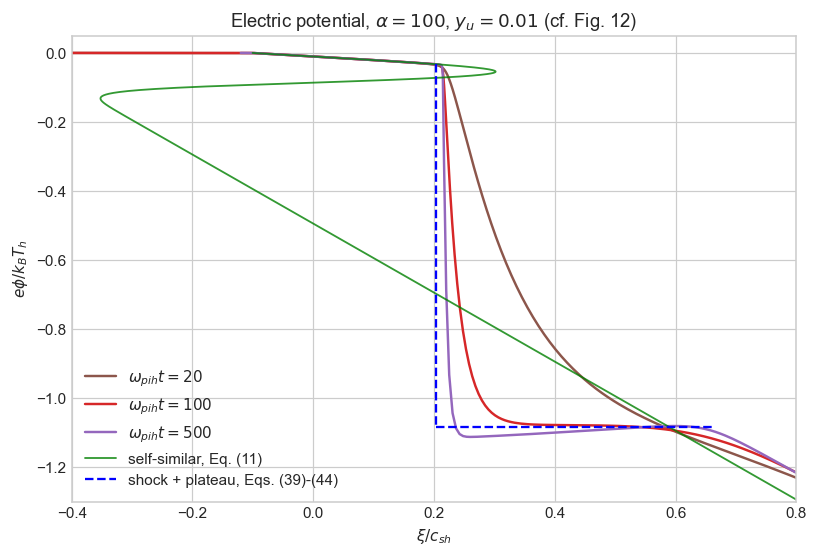

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
colors = {'bimax_t20': 'tab:brown', 'bimax_t100': 'tab:red', 'bimax_t500': 'tab:purple'}
for name in ('bimax_t20', 'bimax_t100', 'bimax_t500'):
    prof = data[name]['profil']
    t = runs[name]['tmax']
    pl = prof[prof['ni'] > 1e-10]
    ax.plot(pl['xt'] / t, -pl['phi'], lw=1.6, color=colors[name],
            label=f"$\\omega_{{pih}} t = {t:.0f}$")
ax.plot(xi_ss, -phi_g, 'g-', lw=1.2, alpha=0.8, label='self-similar, Eq. (11)')
# analytic jump construction: shock at xi_s, plateau to xi_F
ax.plot([xi_s_th, xi_s_th], [-phi0_th, -phi1_th], 'b--', lw=1.5)
ax.plot([xi_s_th, xi_F_th], [-phi1_th, -phi1_th], 'b--', lw=1.5,
        label='shock + plateau, Eqs. (39)-(44)')
ax.set_xlim(-0.4, 0.8)
ax.set_ylim(-1.3, 0.05)
ax.set_xlabel(r'$\xi / c_{sh}$')
ax.set_ylabel(r'$e\phi / k_B T_h$')
ax.set_title(f'Electric potential, $\\alpha = {alpha:.0f}$, $y_u = {yu}$ (cf. Fig. 12)')
ax.legend(loc='lower left')
fig.savefig(viz_dir / 'shock_potential.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Electric field: shock peak and ion-front peak (cf. Fig. 13)

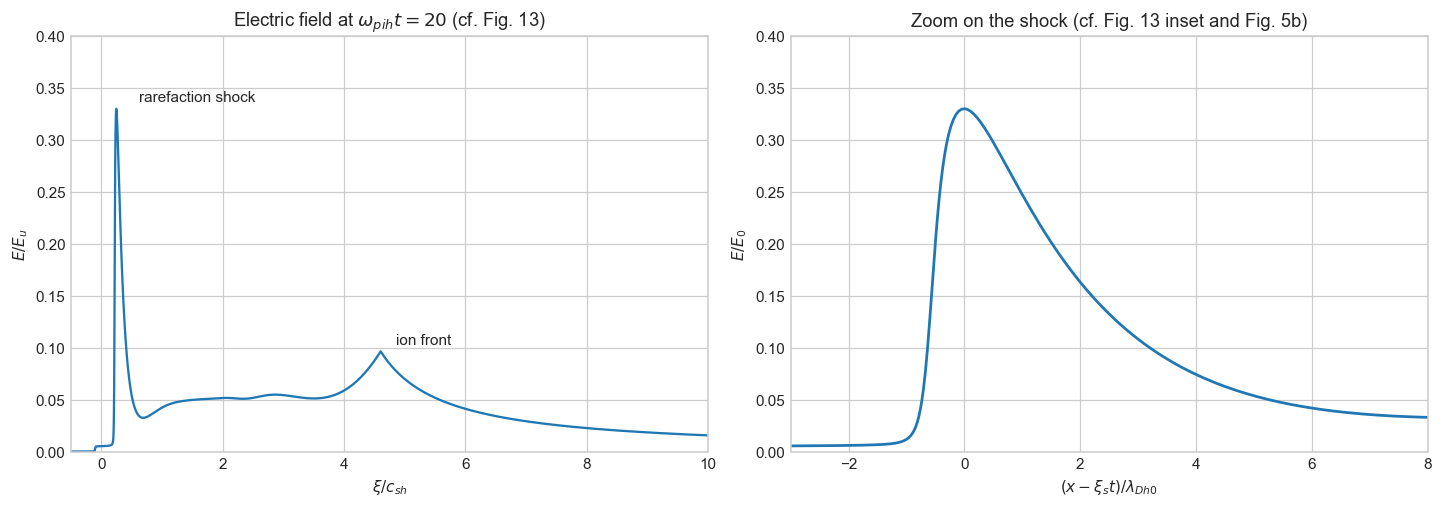

shock peak: E/Eu = 0.330 at xi = 0.248   (paper: ~0.33 at ~0.2; analytic xi_s = 0.202)
front peak: E/Eu = 0.096 at xi = 4.607   (paper: 2 Eu/omega_pih t = 0.100)


In [5]:
prof = data['bimax_t20']['profil']
t = 20.0
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(prof['xt'] / t, prof['E'], lw=1.5)
ax.set_xlim(-0.5, 10)
ax.set_ylim(0, 0.4)
ax.set_xlabel(r'$\xi / c_{sh}$')
ax.set_ylabel(r'$E / E_u$')
ax.set_title(f'Electric field at $\\omega_{{pih}} t = {t:.0f}$ (cf. Fig. 13)')
pl = prof[prof['ni'] > 1e-10]
sel = (pl['xt'] / t > 0) & (pl['xt'] / t < 0.45)
i_shock = pl.loc[sel, 'E'].idxmax()
xi_shock = pl.loc[i_shock, 'xt'] / t
sel2 = prof['xt'] / t > 1.0
i_front = prof.loc[sel2, 'E'].idxmax()
ax.annotate('rarefaction shock', (xi_shock, pl.loc[i_shock, 'E']),
            textcoords='offset points', xytext=(15, 5))
ax.annotate('ion front', (prof.loc[i_front, 'xt'] / t, prof.loc[i_front, 'E']),
            textcoords='offset points', xytext=(10, 5))

ax = axes[1]
X = prof['xt'] - xi_shock * t
ax.plot(X / lam_Dh0, prof['E'], lw=1.8)
ax.set_xlim(-3, 8)
ax.set_ylim(0, 0.4)
ax.set_xlabel(r'$(x - \xi_s t) / \lambda_{Dh0}$')
ax.set_ylabel(r'$E / E_0$')
ax.set_title('Zoom on the shock (cf. Fig. 13 inset and Fig. 5b)')

fig.savefig(viz_dir / 'shock_field.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'shock peak: E/Eu = {pl.loc[i_shock, "E"]:.3f} at xi = {xi_shock:.3f}'
      f'   (paper: ~0.33 at ~0.2; analytic xi_s = {xi_s_th:.3f})')
print(f'front peak: E/Eu = {prof.loc[i_front, "E"]:.3f} at xi = {prof.loc[i_front, "xt"]/t:.3f}'
      f'   (paper: 2 Eu/omega_pih t = {2/t:.3f})')

## 5. Ion front velocity: bi-Maxwellian vs hot-only (cf. Fig. 14)

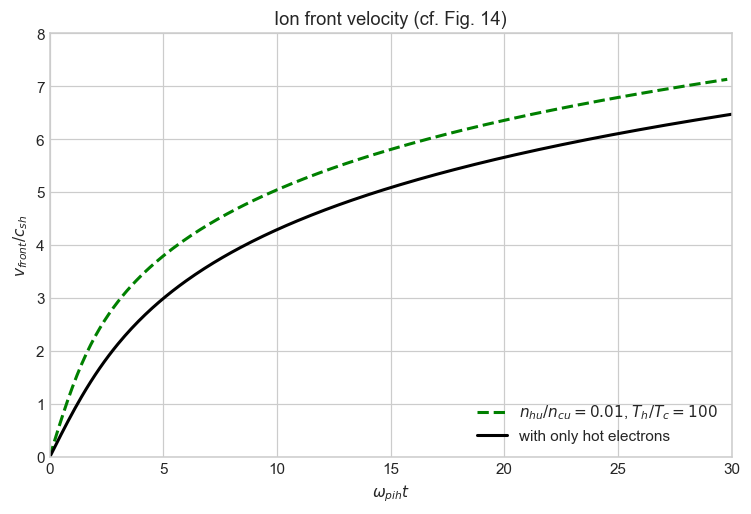

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
hist = data['bimax_t500']['historique']
sel = hist['time'] <= 30
ax.plot(hist.loc[sel, 'time'], hist.loc[sel, 'v(ivmax)'], 'g--', lw=2,
        label=f'$n_{{hu}}/n_{{cu}} = {yu}$, $T_h/T_c = {alpha:.0f}$')
hist_h = data['hot_t30']['historique']
ax.plot(hist_h['time'], hist_h['v(ivmax)'], 'k-', lw=2, label='with only hot electrons')
ax.set_xlim(0, 30)
ax.set_ylim(0, 8)
ax.set_xlabel(r'$\omega_{pih} t$')
ax.set_ylabel(r'$v_{front} / c_{sh}$')
ax.set_title('Ion front velocity (cf. Fig. 14)')
ax.legend(loc='lower right')
fig.savefig(viz_dir / 'shock_front_velocity.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Ion velocity spectrum (cf. Fig. 15)

Normalized as in the paper: $(\lambda_{Dhu}/n_{hu} t)\, dn/dv$ vs $v/c_{sh}$.
The dip is the shock (B–E), the peak just above it is the plateau (E–F), the
exponential tail is the hot-electron expansion.

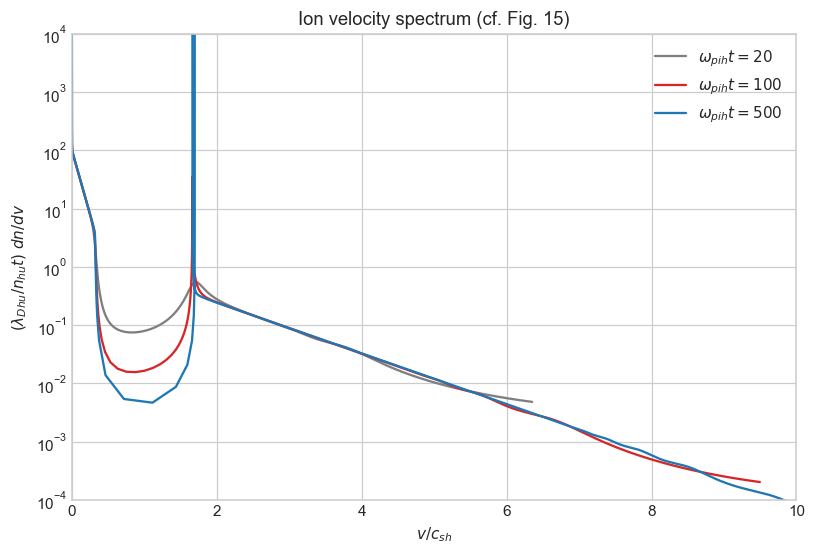

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name, color in (('bimax_t20', 'tab:gray'), ('bimax_t100', 'tab:red'),
                    ('bimax_t500', 'tab:blue')):
    sp = data[name]['spectres']
    t = runs[name]['tmax']
    sel = (sp['vmoy'] > 0) & (sp['dndv'] > 0)
    ax.semilogy(sp.loc[sel, 'vmoy'], sp.loc[sel, 'dndv'] / t, lw=1.5, color=color,
                label=f'$\\omega_{{pih}} t = {t:.0f}$')
ax.set_xlim(0, 10)
ax.set_ylim(1e-4, 1e4)
ax.set_xlabel(r'$v / c_{sh}$')
ax.set_ylabel(r'$(\lambda_{Dhu} / n_{hu} t)\; dn/dv$')
ax.set_title('Ion velocity spectrum (cf. Fig. 15)')
ax.legend()
fig.savefig(viz_dir / 'shock_spectrum.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Supersonic rarefaction shock: $y_u > y_B$ (Sec. III D, cf. Figs. 7–9)

For $y_u = 10 > y_B \approx 0.28$ the cold-dominated expansion region
disappears: the unperturbed plasma connects **directly** to the rarefaction
shock, which propagates into it *supersonically*. The Hugoniot relation
(Eq. 30) holds with $y_0 = y_u$; since the upstream plasma is at rest, the
shock moves at $\xi_s = -u_0$ with $u_0 > c_s(y_u)$.

The paper's Sec. IV only simulated the standard case — Figs. 7–9 are
analytic — so this section is a numerical test the paper itself did not run.
The foil depth is chosen per run so the shock (at $0.675\,c_{sh}$) never
reaches the rear side.

In [8]:
yu_s = 10.0
ncu_s = nhu / yu_s

# Hugoniot (Eq. 30) with y0 = yu, solved by bisection for the potential jump w
# (w = 0 is a trivial tangent root; the physical root is the nonzero one)
def hugoniot_residual(w):
    rhs = 0.5 * (yu_s * (1 - np.exp(-w)) + (1 - np.exp(-alpha * w)) / alpha) * \
          (1 / (yu_s + 1) + 1 / (yu_s * np.exp(-w) + np.exp(-alpha * w)))
    return rhs - w


lo, hi = 0.1, 0.8      # residual < 0 at lo, > 0 at hi
for _ in range(100):
    mid = 0.5 * (lo + hi)
    if hugoniot_residual(mid) < 0:
        lo = mid
    else:
        hi = mid
w_s = 0.5 * (lo + hi)
u0_s = np.sqrt(2 * w_s / (((yu_s + 1) / (yu_s * np.exp(-w_s) + np.exp(-alpha * w_s)))**2 - 1))
u1_s = np.sqrt(u0_s**2 + 2 * w_s)                      # Eq. (32)
cs_u = np.sqrt((1 + yu_s) / (alpha + yu_s))            # Eq. (28) at yu
xi_s_sup = -u0_s                                       # upstream plasma at rest
Mach = u0_s / cs_u

# self-similar curve (Eq. 11) for this composition
def cs_sup(phi):
    ne = nhu * np.exp(-phi / Th) + ncu_s * np.exp(-phi / Tc)
    return np.sqrt(ne / (nhu / Th * np.exp(-phi / Th) + ncu_s / Tc * np.exp(-phi / Tc)))


phi_gs = np.linspace(0.0, 1.7, 20000)
cs_gs = cs_sup(phi_gs)
xi_sss = np.concatenate(([0.0], np.cumsum(0.5 * (1 / cs_gs[1:] + 1 / cs_gs[:-1]) * np.diff(phi_gs))))
xi_sss -= cs_gs - cs_gs[0]
xi_sss -= cs_gs[0]
xi_F_sup = float(np.interp(w_s, phi_gs, xi_sss))       # F: self-similar point at phi = w

print(f'supersonic case: w = {w_s:.3f}, u0 = {u0_s:.3f} csh, u1 = {u1_s:.3f} csh')
print(f'cs(yu) = {cs_u:.3f} csh  ->  Mach = {Mach:.2f} (supersonic)')
print(f'shock at xi_s = {xi_s_sup:.3f}, plateau to xi_F = {xi_F_sup:.3f}')

runs_s = {
    'sup_t20': dict(tmax=20.0, cold=True, ncold=ncu_s, lmax=40.0),
    'sup_t100': dict(tmax=100.0, cold=True, ncold=ncu_s, lmax=90.0, ncell=3000, prog=0.998),
    'sup_t300': dict(tmax=300.0, cold=True, ncold=ncu_s, lmax=230.0, ncell=4500, prog=0.999),
}
for name, kw in runs_s.items():
    wdir = build_dir / name
    wdir.mkdir(exist_ok=True)
    (wdir / 'input.in').write_text(input_text(**kw))
    sh(build_dir / 'ionboost', cwd=wdir)
    data[name] = {f: read_solver_table(wdir / f'{f}.txt')
                  for f in ('profil', 'spectres', 'historique')}
    print(f'{name}: done')

supersonic case: w = 0.449, u0 = 0.675 csh, u1 = 1.163 csh
cs(yu) = 0.316 csh  ->  Mach = 2.14 (supersonic)
shock at xi_s = -0.675, plateau to xi_F = -0.521
sup_t20: done


sup_t100: done


sup_t300: done


### Electric potential (cf. Fig. 7)

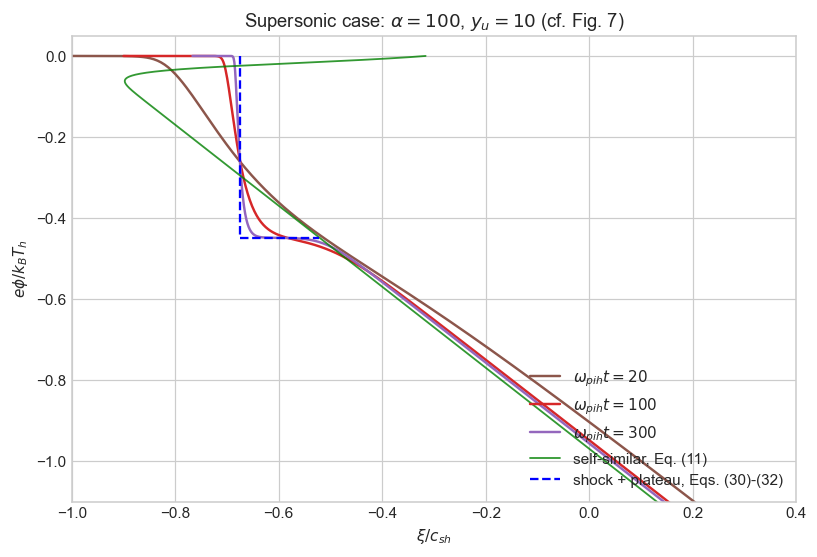

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
colors_s = {'sup_t20': 'tab:brown', 'sup_t100': 'tab:red', 'sup_t300': 'tab:purple'}
for name in runs_s:
    prof = data[name]['profil']
    t = runs_s[name]['tmax']
    pl = prof[prof['ni'] > 1e-10]
    ax.plot(pl['xt'] / t, -pl['phi'], lw=1.6, color=colors_s[name],
            label=f"$\\omega_{{pih}} t = {t:.0f}$")
ax.plot(xi_sss, -phi_gs, 'g-', lw=1.2, alpha=0.8, label='self-similar, Eq. (11)')
ax.plot([xi_s_sup, xi_s_sup], [0, -w_s], 'b--', lw=1.5)
ax.plot([xi_s_sup, xi_F_sup], [-w_s, -w_s], 'b--', lw=1.5,
        label='shock + plateau, Eqs. (30)-(32)')
ax.set_xlim(-1.0, 0.4)
ax.set_ylim(-1.1, 0.05)
ax.set_xlabel(r'$\xi / c_{sh}$')
ax.set_ylabel(r'$e\phi / k_B T_h$')
ax.set_title(f'Supersonic case: $\\alpha = {alpha:.0f}$, $y_u = {yu_s:.0f}$ (cf. Fig. 7)')
ax.legend(loc='lower right')
fig.savefig(viz_dir / 'shock_supersonic_potential.png', dpi=200, bbox_inches='tight')
plt.show()

### Shock speed and Mach number

In [10]:
print('measured shock position (E-field peak inside the plasma) vs theory:')
print(f'{"t":>6} {"xi_shock":>10} {"theory":>10}')
xs, ts = [], []
for name in runs_s:
    prof = data[name]['profil']
    t = runs_s[name]['tmax']
    pl = prof[prof['ni'] > 1e-10]
    sel = pl['xt'] / t < 0.0
    i_pk = pl.loc[sel, 'E'].idxmax()
    xs.append(pl.loc[i_pk, 'xt'])
    ts.append(t)
    print(f'{t:6.0f} {pl.loc[i_pk, "xt"]/t:10.3f} {xi_s_sup:10.3f}')
speed = np.polyfit(ts, xs, 1)[0]
print(f'\nfitted shock speed = {speed:.3f} csh   (theory: {xi_s_sup:.3f})')
print(f'measured Mach = {abs(speed)/cs_u:.2f}          (theory: {Mach:.2f})')

measured shock position (E-field peak inside the plasma) vs theory:
     t   xi_shock     theory
    20     -0.745     -0.675
   100     -0.691     -0.675
   300     -0.681     -0.675

fitted shock speed = -0.677 csh   (theory: -0.675)
measured Mach = 2.14          (theory: 2.14)


### Ion velocity spectrum, supersonic case

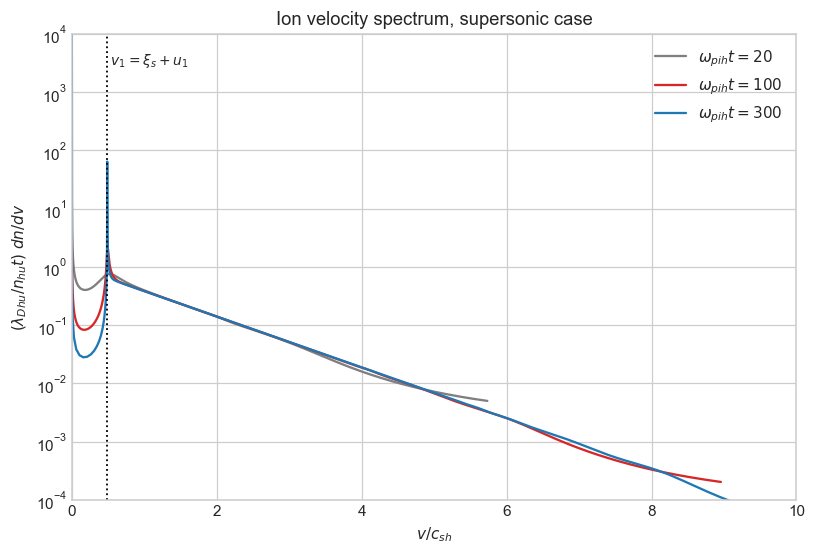

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name, color in (('sup_t20', 'tab:gray'), ('sup_t100', 'tab:red'),
                    ('sup_t300', 'tab:blue')):
    sp = data[name]['spectres']
    t = runs_s[name]['tmax']
    sel = (sp['vmoy'] > 0) & (sp['dndv'] > 0)
    ax.semilogy(sp.loc[sel, 'vmoy'], sp.loc[sel, 'dndv'] / t, lw=1.5, color=color,
                label=f'$\\omega_{{pih}} t = {t:.0f}$')
v1_lab = xi_s_sup + u1_s   # downstream flow velocity in the lab frame
ax.axvline(v1_lab, color='k', ls=':', lw=1.2)
ax.text(v1_lab, 3e3, r' $v_1 = \xi_s + u_1$', fontsize=9)
ax.set_xlim(0, 10)
ax.set_ylim(1e-4, 1e4)
ax.set_xlabel(r'$v / c_{sh}$')
ax.set_ylabel(r'$(\lambda_{Dhu} / n_{hu} t)\; dn/dv$')
ax.set_title('Ion velocity spectrum, supersonic case')
ax.legend()
fig.savefig(viz_dir / 'shock_supersonic_spectrum.png', dpi=200, bbox_inches='tight')
plt.show()

## Notes

- The cold population is declared by the optional 10th line of `input.in`
  (`n0cold Tcmax`); without it the solver is the single-species Mora (2003) code.
- At $\omega_{pih} t = 20$ the shock front is still smoothed by charge
  separation; it converges to the analytic jump + plateau by
  $\omega_{pih} t = 100$–$500$, exactly as in Fig. 12 of the paper.
- The vacuum sheath beyond the ion front uses the hot population only
  (exact once $e\phi_{front} \gg k_B T_c$).